# 1. Load All Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

# 2. Load the Cleaned File

In [2]:
df = pd.read_csv('D:\\Hospital_Performance_Dashboard\\Hospital_Clean_Data.csv')
df.head()

,Patient_ID,Age,Gender,Department,Diagnosis,Severity_Level,Length_of_Stay_Days,Wait_Time_Minutes,Doctor_ID,Insurance_Type,Treatment_Cost_USD,Readmission_Flag,Outcome,Cost_Per_Day_USD,Age_Group,Wait_Time_Bucket,Stay_Category,Severity_Score,Readmitted
0,PAT000001,23,Male,Gynecology,Cancer,Low,2,79,DOC0350,Employer,485.0,0.0,Recovered,242.50,Young Adult (19-35),1-2 hr,Short (2-3d),1.0,No
1,PAT000002,48,Male,Neurology,Kidney Disease,Medium,6,167,DOC0267,Private,3487.0,0.0,Improved,581.17,Adult (36-50),2-3 hr,Medium (4-7d),2.0,No
2,PAT000003,48,Male,Neurology,Stroke,Low,3,281,DOC0197,Self-Pay,716.0,0.0,Recovered,238.67,Adult (36-50),3-5 hr,Short (2-3d),1.0,No
3,PAT000004,85,Male,Emergency,Asthma,Medium,2,271,DOC0009,Government,2111.0,0.0,Recovered,1055.50,Elderly (65+),3-5 hr,Short (2-3d),2.0,No
4,PAT000005,93,Female,Neurology,Pneumonia,Medium,7,112,DOC0219,Self-Pay,4968.0,0.0,Transferred,709.71,Elderly (65+),1-2 hr,Medium (4-7d),2.0,No


# 3. Exploratory Data Analysis (EDA)

### 3.1 Univariate Analysis Numeric Distribution

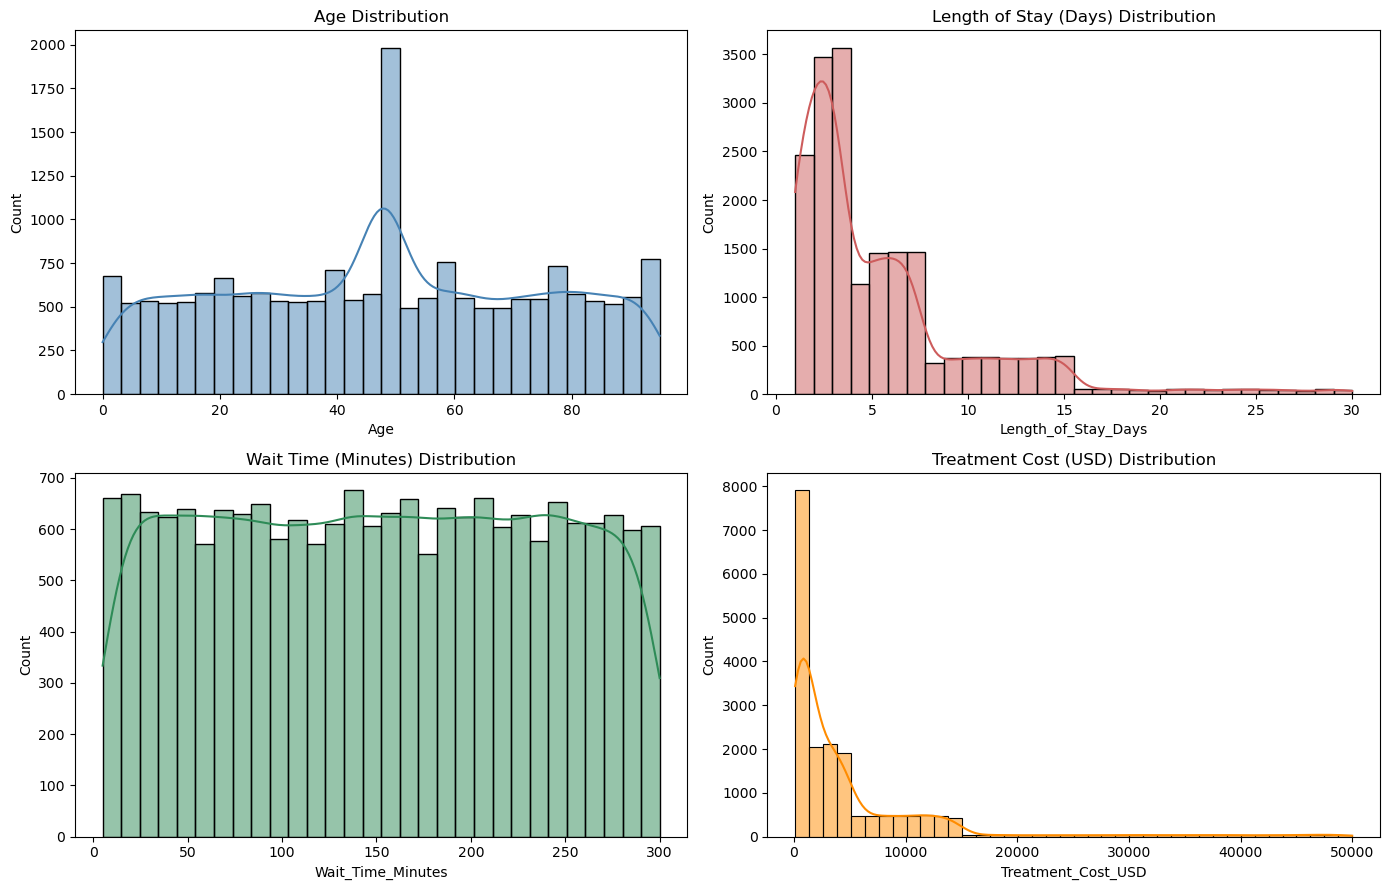

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(df['Age'], bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['Length_of_Stay_Days'], bins=30, kde=True, ax=axes[0, 1], color='indianred')
axes[0, 1].set_title('Length of Stay (Days) Distribution')

sns.histplot(df['Wait_Time_Minutes'], bins=30, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Wait Time (Minutes) Distribution')

sns.histplot(df['Treatment_Cost_USD'], bins=40, kde=True, ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Treatment Cost (USD) Distribution')

plt.tight_layout()
plt.show()


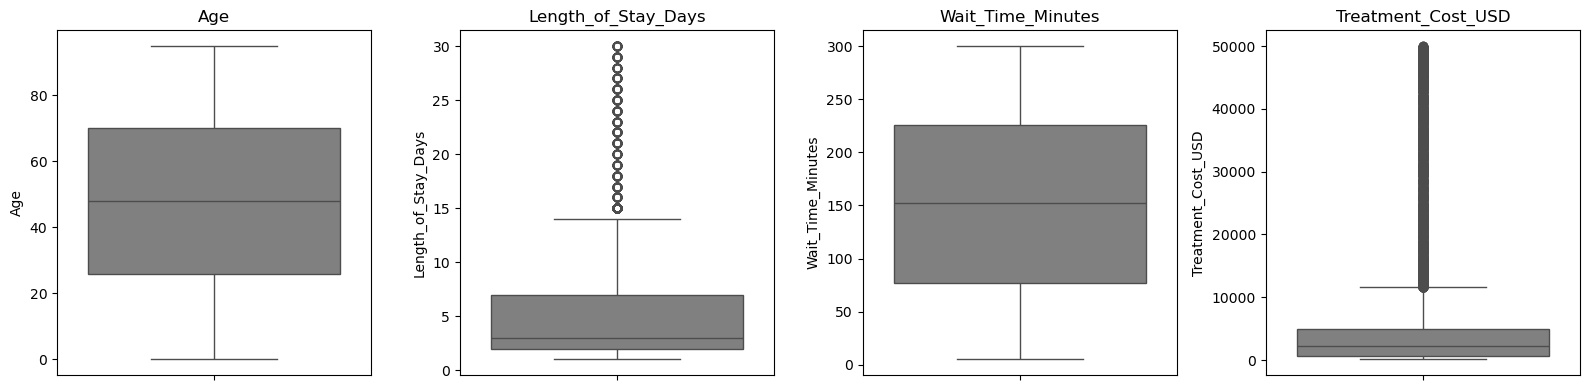

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ['Age', 'Length_of_Stay_Days', 'Wait_Time_Minutes', 'Treatment_Cost_USD']):
    sns.boxplot(y=df[col], ax=ax, color='gray')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 3.2 Univariate Analysis Categorical Counts

C:\Users\admin\AppData\Local\Temp\ipykernel_8896\893509261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
C:\Users\admin\AppData\Local\Temp\ipykernel_8896\893509261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
C:\Users\admin\AppData\Local\Temp\ipykernel_8896\893509261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
C:\Users\admin\AppData\Local\Temp\ipykernel_8896\893509261

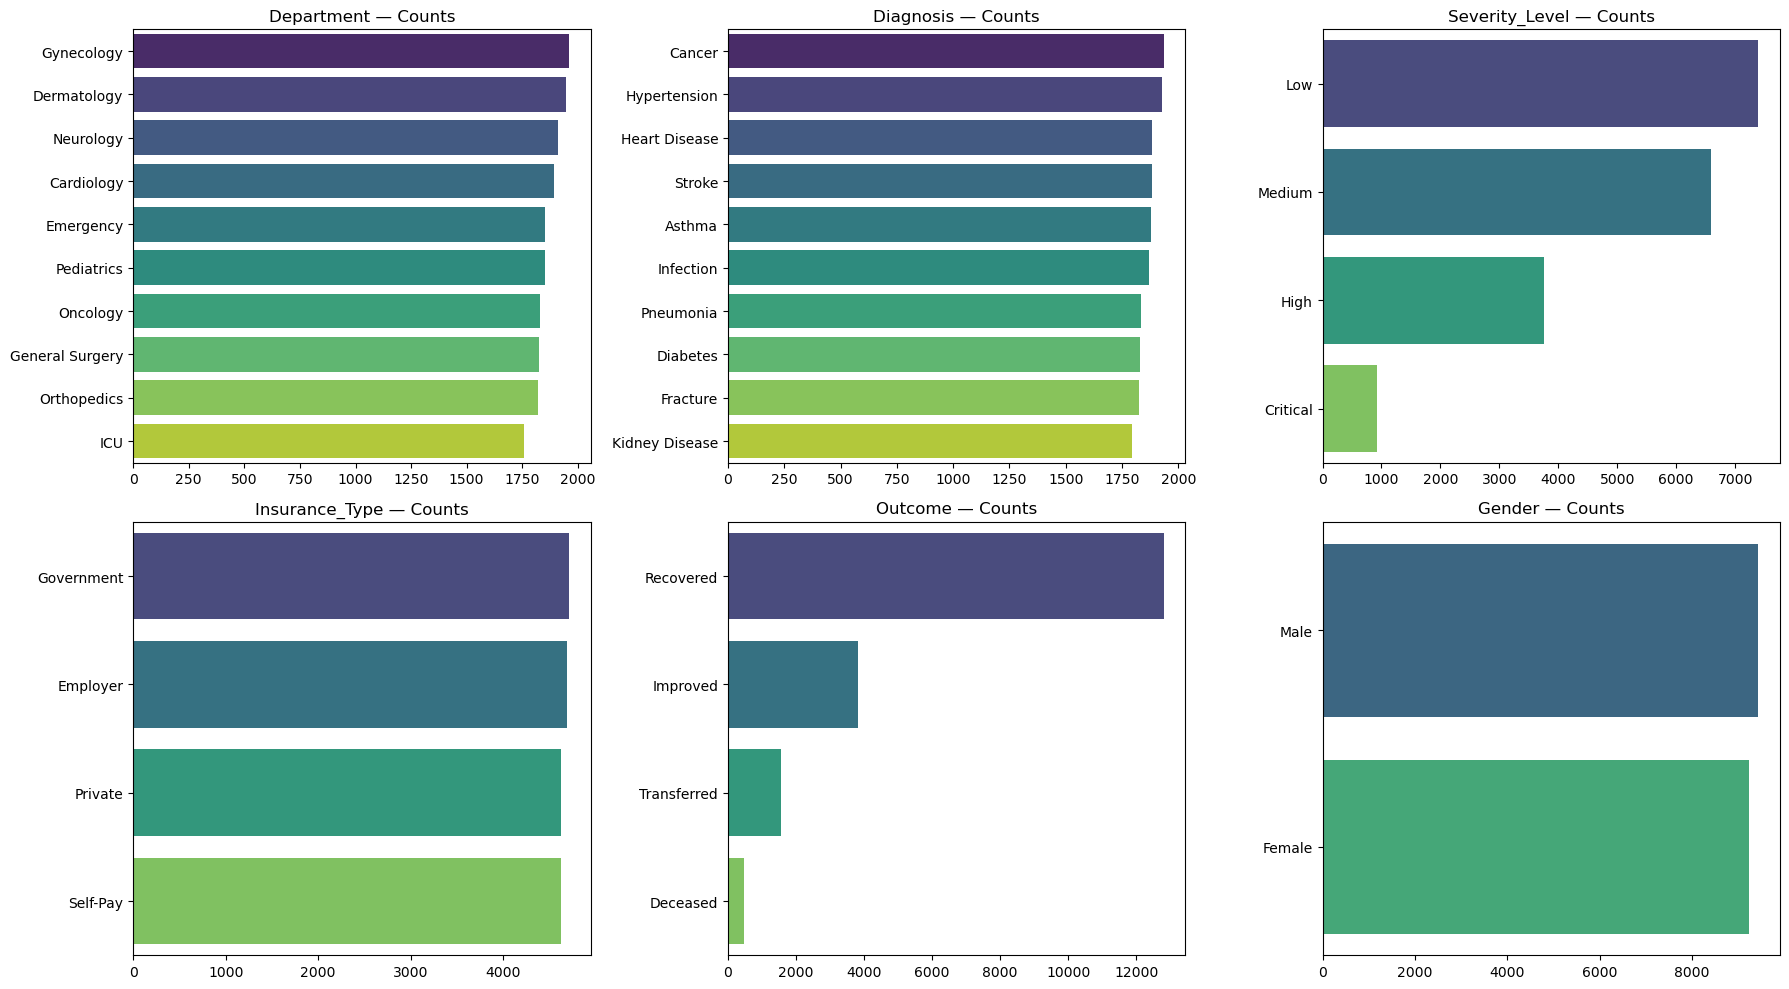

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cat_plot_cols = ['Department', 'Diagnosis', 'Severity_Level', 'Insurance_Type', 'Outcome', 'Gender']

for ax, col in zip(axes.flat, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, palette='viridis')
    ax.set_title(f'{col} — Counts')
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()


### 3.3 Bivariate Analysis

C:\Users\admin\AppData\Local\Temp\ipykernel_8896\2975350126.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Department', y='Treatment_Cost_USD', order=order_dept, ax=axes[0], palette='crest')
C:\Users\admin\AppData\Local\Temp\ipykernel_8896\2975350126.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Severity_Level', y='Length_of_Stay_Days',


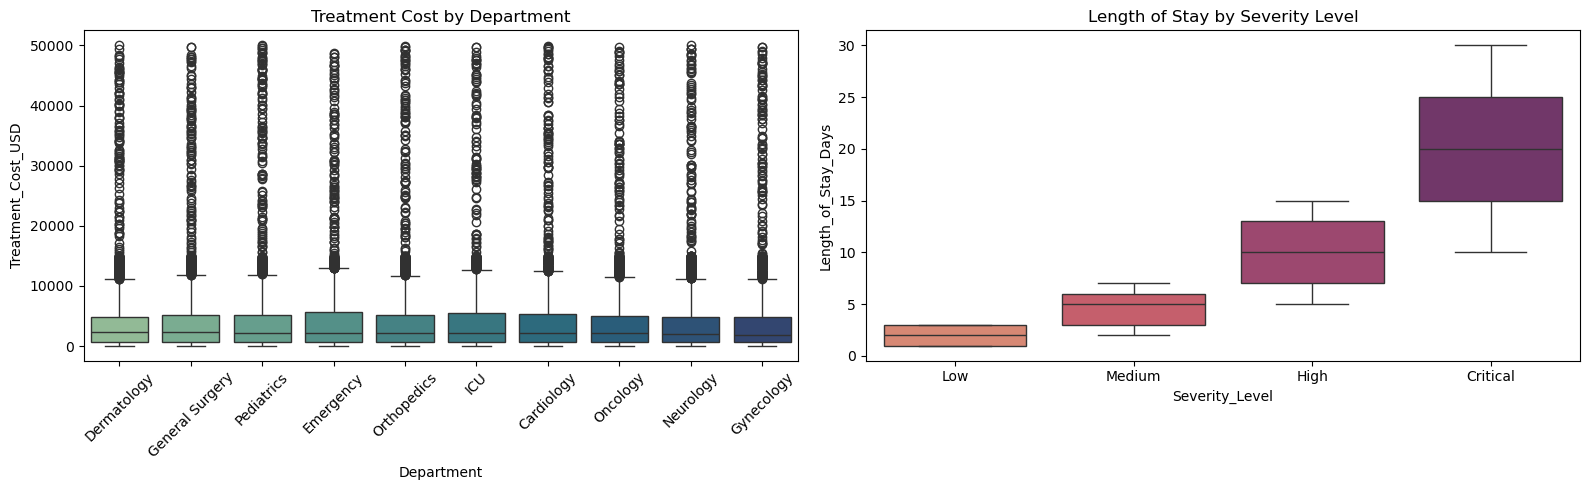

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

order_dept = df.groupby('Department', observed=True)['Treatment_Cost_USD'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Department', y='Treatment_Cost_USD', order=order_dept, ax=axes[0], palette='crest')
axes[0].set_title('Treatment Cost by Department')
axes[0].tick_params(axis='x', rotation=45)

severity_order_list = ['Low', 'Medium', 'High', 'Critical']
sns.boxplot(data=df, x='Severity_Level', y='Length_of_Stay_Days',
            order=[s for s in severity_order_list if s in df['Severity_Level'].unique()],
            ax=axes[1], palette='flare')
axes[1].set_title('Length of Stay by Severity Level')

plt.tight_layout()
plt.show()


C:\Users\admin\AppData\Local\Temp\ipykernel_8896\1605842546.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette='mako')


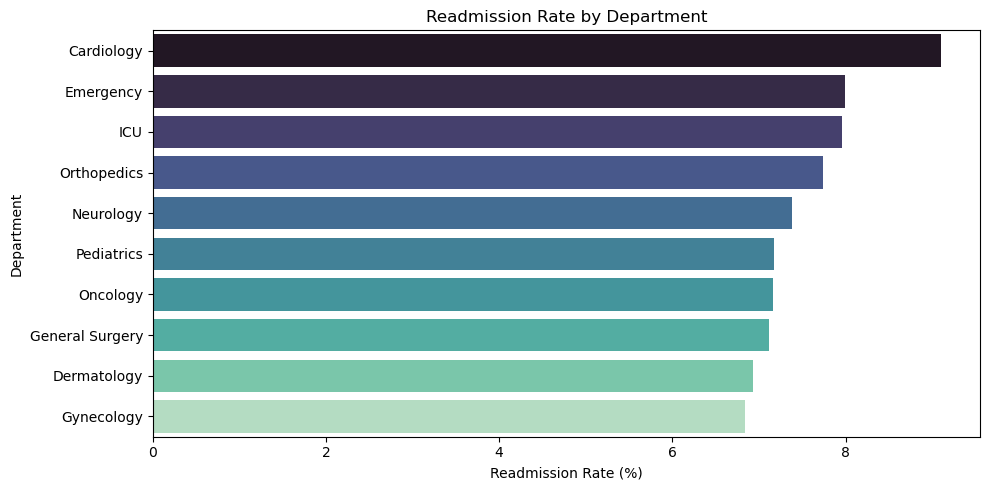

Department
Cardiology         9.1
Emergency          8.0
ICU                8.0
Orthopedics        7.7
Neurology          7.4
Pediatrics         7.2
Oncology           7.2
General Surgery    7.1
Dermatology        6.9
Gynecology         6.8
Name: Readmission_Flag, dtype: float64

In [8]:
plt.figure(figsize=(10, 5))
readmit_rate = df.groupby('Department', observed=True)['Readmission_Flag'].mean().sort_values(ascending=False) * 100
sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette='mako')
plt.xlabel('Readmission Rate (%)')
plt.title('Readmission Rate by Department')
plt.tight_layout()
plt.show()

readmit_rate.round(1)


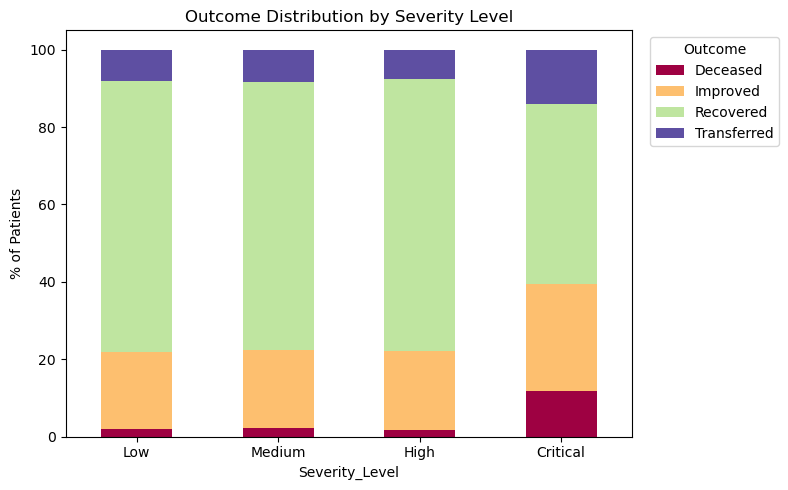

In [11]:
plt.figure(figsize=(8, 5))
outcome_severity = pd.crosstab(df['Severity_Level'], df['Outcome'], normalize='index') * 100
outcome_severity = outcome_severity.reindex([s for s in severity_order_list if s in df['Severity_Level'].unique()])
outcome_severity.plot(kind='bar', stacked=True, colormap='Spectral', ax=plt.gca())
plt.ylabel('% of Patients')
plt.title('Outcome Distribution by Severity Level')
plt.legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


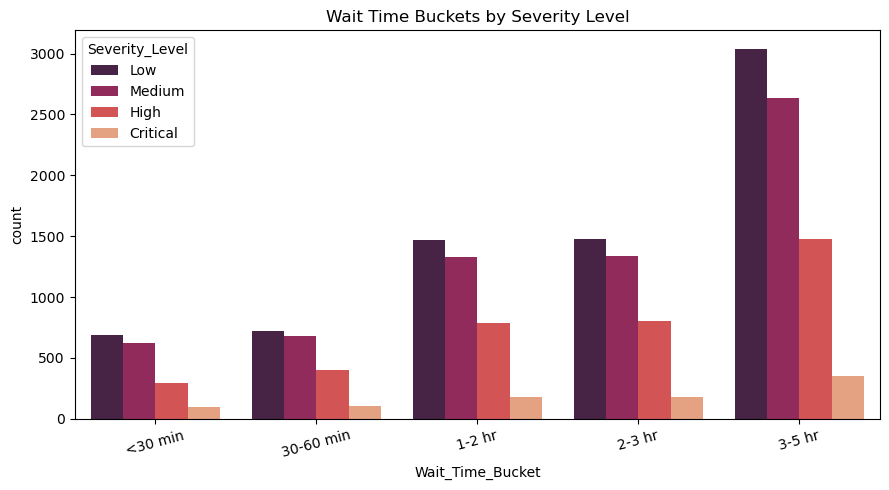

In [12]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Wait_Time_Bucket',
              order=['<30 min', '30-60 min', '1-2 hr', '2-3 hr', '3-5 hr'],
              hue='Severity_Level', hue_order=[s for s in severity_order_list if s in df['Severity_Level'].unique()],
              palette='rocket')
plt.title('Wait Time Buckets by Severity Level')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### 3.4 Coorelation Analysis

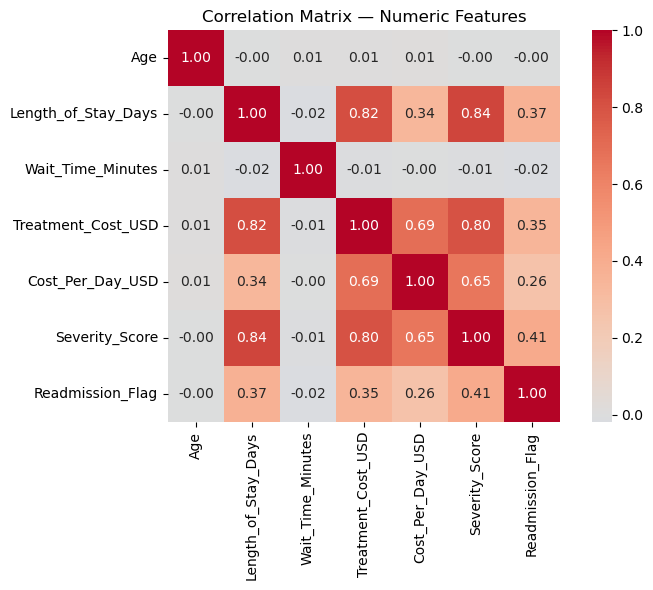

In [13]:
plt.figure(figsize=(8, 6))
corr_cols = ['Age', 'Length_of_Stay_Days', 'Wait_Time_Minutes', 'Treatment_Cost_USD',
             'Cost_Per_Day_USD', 'Severity_Score', 'Readmission_Flag']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


### 3.5 Insuarance Type vs Cost & Outcome

C:\Users\admin\AppData\Local\Temp\ipykernel_8896\2860822629.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Insurance_Type', y='Treatment_Cost_USD', ax=axes[0], palette='pastel')


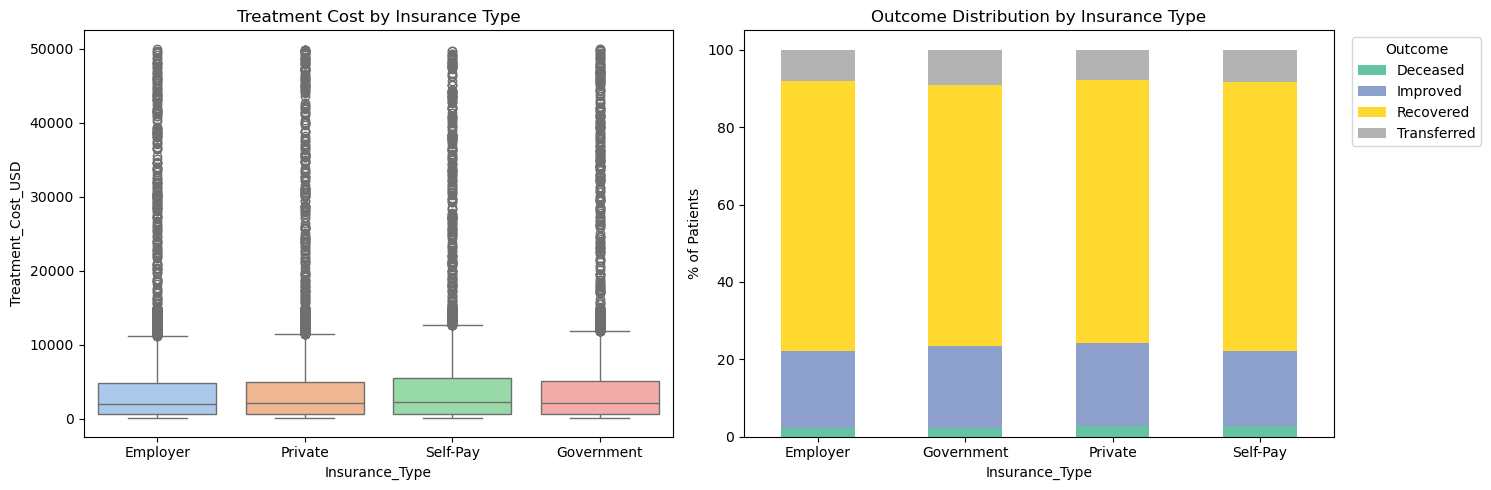

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x='Insurance_Type', y='Treatment_Cost_USD', ax=axes[0], palette='pastel')
axes[0].set_title('Treatment Cost by Insurance Type')

insurance_outcome = pd.crosstab(df['Insurance_Type'], df['Outcome'], normalize='index') * 100
insurance_outcome.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Outcome Distribution by Insurance Type')
axes[1].set_ylabel('% of Patients')
axes[1].legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
